In [1]:
%load_ext autoreload
%autoreload 2

'''
Importing the modules
'''
import config_2D_coupling_V3 as cfg         # config = physical & simulation parameters 
from solver_2D_coupling_V3 import *         # solver = FEM method + pmls
import post_process_2D_coupling_V2 as my_pp # post_process = plotting functions
from ngsolve import exp 
import numpy as np  


In [2]:
from ngsolve import exp, IfPos, sqrt
import numpy as np

def create_density_profile(x_sym, z_sym):
    '''
    Define a 2D (x,z) arbitrary profile of density n_e(x,z).
    Upgraded with a Smoothed Heaviside blending to keep strictly linear segments
    while ensuring C1 continuity locally at the junctions to prevent FEM reflections.
    '''
    # TYPE: str
    prof_type = cfg.PLASMA.get('profile_type', 'exponential')

    if prof_type == 'constant_density':
        # TYPE: float
        return cfg.PLASMA['ne_constant']

    elif prof_type == 'exponential_density':
        # TYPE: float
        Lx_plasma = cfg.DOMAIN['Lx_plasma']
        n_edge = cfg.PLASMA['lin_prof_n'][0]
        n_core = cfg.PLASMA['lin_prof_n'][-1]

        # TYPE: float
        lambda_val = np.log(n_core / n_edge) / Lx_plasma
        
        # TYPE: ngsolve.CoefficientFunction
        n_e_profile = n_edge * exp(lambda_val * x_sym)
        return n_e_profile

    elif prof_type == 'piecewise_linear_density':
        # TYPE: np.ndarray, SHAPE: (N,)
        x_pts = np.array(cfg.PLASMA['lin_prof_x'])
        n_pts = np.array(cfg.PLASMA['lin_prof_n'])

        # Smoothing parameter (e.g., 0.002 meters = 2 mm transition zone)
        # TYPE: float
        smooth_width = 0.002 

        # Initialize the profile with the very first linear segment
        # TYPE: float
        slope_0 = (n_pts[1] - n_pts[0]) / (x_pts[1] - x_pts[0])
        
        # TYPE: ngsolve.CoefficientFunction
        n_e_profile = n_pts[0] + slope_0 * (x_sym - x_pts[0])

        # Sequentially blend the next segments using a Smoothed Heaviside step
        for i in range(1, len(x_pts) - 1):
            # TYPE: float
            x_c = x_pts[i]
            n_c = n_pts[i]
            
            # TYPE: float
            slope_prev = (n_pts[i] - n_pts[i-1]) / (x_pts[i] - x_pts[i-1])
            slope_next = (n_pts[i+1] - n_pts[i]) / (x_pts[i+1] - x_pts[i])

            # Line equations for previous and next segments
            # TYPE: ngsolve.CoefficientFunction
            L_prev = n_c + slope_prev * (x_sym - x_c)
            L_next = n_c + slope_next * (x_sym - x_c)

            # Smoothed Heaviside transition centered at x_c
            # TYPE: ngsolve.CoefficientFunction
            dx = x_sym - x_c
            H_smooth = 0.5 * (1.0 + dx / sqrt(dx**2 + smooth_width**2))

            # Add the difference modulated by the smooth transition
            n_e_profile = n_e_profile + (L_next - L_prev) * H_smooth

        return n_e_profile

    elif prof_type == 'piecewise_linear_brute':
        # Pure C0 piecewise linear with sharp corners (for benchmarking reflections)
        # TYPE: np.ndarray, SHAPE: (N,)
        x_pts = np.array(cfg.PLASMA['lin_prof_x'])
        n_pts = np.array(cfg.PLASMA['lin_prof_n'])

        # TYPE: float | ngsolve.CoefficientFunction
        n_e_profile = 0.0

        for i in range(len(x_pts) - 1):
            # TYPE: float
            x0, x1 = x_pts[i], x_pts[i+1]
            n0, n1 = n_pts[i], n_pts[i+1]

            # TYPE: float
            slope = (n1 - n0) / (x1 - x0)
            
            # TYPE: ngsolve.CoefficientFunction
            line = n0 + slope * (x_sym - x0)

            # TYPE: ngsolve.CoefficientFunction
            if i == len(x_pts) - 2:
                mask = IfPos(x_sym - x0, 1.0, 0.0)
            else:
                mask = IfPos(x_sym - x0, 1.0, 0.0) - IfPos(x_sym - x1, 1.0, 0.0)

            n_e_profile = n_e_profile + mask * line

        return n_e_profile

    else:
        raise ValueError("Profile type not supported. Use 'exponential_density', 'piecewise_linear_density', or 'piecewise_linear_brute'.")

In [3]:
def create_density_profile(x_val,z_val):
    """
    Unified density profile calculator using Numpy. 
    Matches the mathematical logic used in the FEM solver.
    """
    # TYPE prof_type: str
    prof_type = cfg.PLASMA.get('profile_type', 'constant_density')
    
    if prof_type == 'constant_density':
        # TYPE ne_constant: float
        ne_constant = cfg.PLASMA['ne_constant']
        # TYPE: np.ndarray
        return np.full_like(x_val, ne_constant)

    elif prof_type == 'exponential_density':
        # TYPE Lx_plasma: float
        Lx_plasma = cfg.DOMAIN['Lx_plasma']
        # TYPE n_edge, n_core: float
        n_edge = cfg.PLASMA['lin_prof_n'][0]
        n_core = cfg.PLASMA['lin_prof_n'][-1]
        # TYPE lambda_val: float
        lambda_val = np.log(n_core / n_edge) / Lx_plasma
        # TYPE: np.ndarray
        return n_edge * np.exp(lambda_val * x_val)

    elif prof_type == 'piecewise_linear_density':
        # TYPE x_pts, n_pts: np.ndarray
        x_pts = np.array(cfg.PLASMA['lin_prof_x'])
        n_pts = np.array(cfg.PLASMA['lin_prof_n'])
        # TYPE smooth_width: float (Transition zone in meters, e.g. 2mm)
        smooth_width = cfg.PLASMA.get('smooth_width', 0.002)
        
        # TYPE slope_0: float
        slope_0 = (n_pts[1] - n_pts[0]) / (x_pts[1] - x_pts[0])
        # TYPE profile: np.ndarray
        profile = n_pts[0] + slope_0 * (x_val - x_pts[0])

        # Apply smoothed transitions at each junction point
        for i in range(1, len(x_pts) - 1):
            # TYPE x_c, n_c: float
            x_c, n_c = x_pts[i], n_pts[i]
            # TYPE s_prev, s_next: float
            s_prev = (n_pts[i] - n_pts[i-1]) / (x_pts[i] - x_pts[i-1])
            s_next = (n_pts[i+1] - n_pts[i]) / (x_pts[i+1] - x_pts[i])
            
            # Linear equations for previous and next segments
            # TYPE L_prev, L_next: np.ndarray
            L_prev = n_c + s_prev * (x_val - x_c)
            L_next = n_c + s_next * (x_val - x_c)
            
            # Smoothed Heaviside transition centered at junction x_c
            # TYPE dx, H_smooth: np.ndarray
            print('type x_val: ', type(x_val))
            print('type x_c: ', type(x_c))
            dx = x_val - x_c
            H_smooth = 0.5 * (1.0 + dx / np.sqrt(dx**2 + smooth_width**2))
            
            # Blend the difference between the two lines
            profile += (L_next - L_prev) * H_smooth
            
        return profile
        
    else:
        print(f"[WARNING] Unknown profile type '{prof_type}'. Returning zeros.")
        return np.zeros_like(x_val)

In [4]:
# 1. Solver initialization
solver = LHCouplingSolver(cfg.__dict__)
solver.build_mesh()

# 2. Physics implementation + solving system
print("--- Introducing n_e profile in General Stix Tensor ---")
solver.build_physics(lambda x_sym, z_sym: my_pp.create_density_profile(x_sym, z_sym, solver))
solver.solve_system()

Degrees of freedom: 381501
--- Introducing n_e profile in General Stix Tensor ---
create_density_profile: prof_type =  constant_density


NgException: SymblicBFI needs scalar-valued CoefficientFunction

--- Post-Processing ---
sim_target_folder:  /home/remi/Perso/Stage/M2_IRFM/Codes/LH_2D_Coupling/
--- 2D map generation of (norm) ---
len(x_vals) =  300 len(z_vals) =  200
len(X) =  300 len(Z) =  300
resolution_x =  300 resolution_z =  200
Max norm amplitude detected in grid: 2.4928e+02 V/m
x_cutoff computation

--- Computing Density Map & Cutoff ---
Lx_tot=  0.2 Lx_plasma=  0.1 Lz_tot=  0.5051249432432433
len(X):  300
len(Z):  300
Selected density profile: constant_density
create_density_profile: prof_type =  constant_density
Computed Cutoff Density (n_c): 1.6982e+17 m^-3
Cutoff layer dynamically located at x = 0.0000 m
Add B vect to the graph 


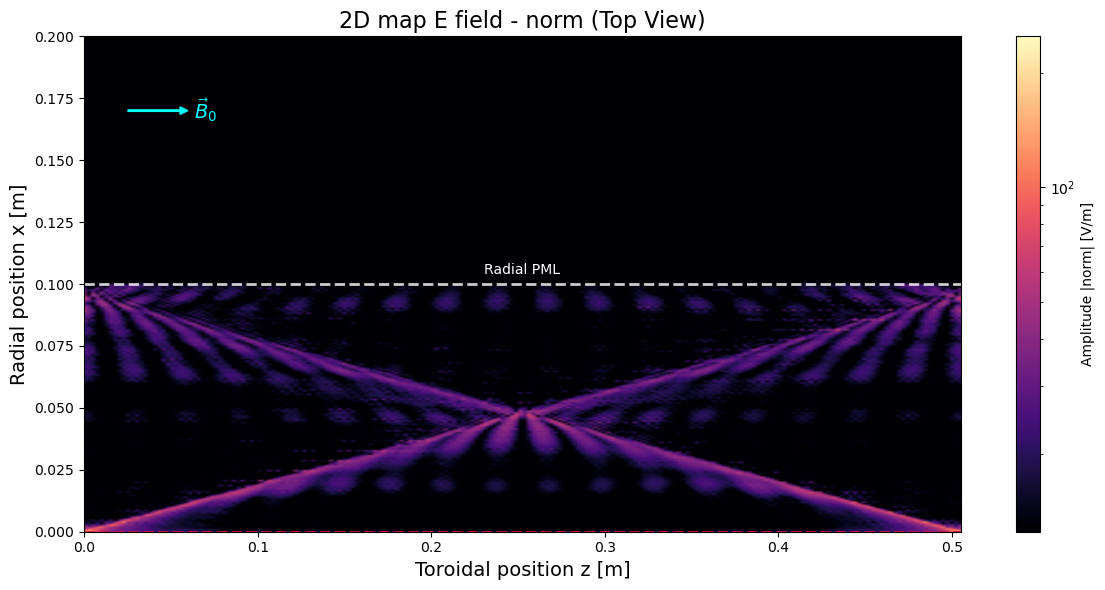

--- Plot E field Function End---


In [ ]:
# 3. Post processing
print("--- Post-Processing ---")


# run_folder = my_pp.setup_output_directory("Simulation_Results")
# print('run_folder', run_folder)
# my_pp.save_configuration(cfg.__dict__, run_folder)

sim_target_folder = "/home/remi/Perso/Stage/M2_IRFM/Codes/LH_2D_Coupling/"#  + run_folder
print('sim_target_folder: ', sim_target_folder)
resolution_x, resolution_z = 300, 200

my_pp.Plot_E_field_2D_Map(solver, sim_target_folder, resolution_x, resolution_z, component ='norm')


--- Extraction and mean on z of radiale profile components ---
--- Plot Radial Component Av.: components =  [array([6.55995561e+00, 6.22925412e+00, 6.30574480e+00, 5.98119590e+00,
       5.97062701e+00, 5.82008692e+00, 5.69023553e+00, 5.84212264e+00,
       6.28521198e+00, 6.12830049e+00, 6.74467606e+00, 6.61539256e+00,
       7.35450162e+00, 7.17098470e+00, 7.69713671e+00, 7.58124977e+00,
       8.01864611e+00, 8.06027770e+00, 8.44420236e+00, 8.61563057e+00,
       8.79063424e+00, 9.20802197e+00, 1.05754220e+01, 9.64995192e+00,
       1.02261650e+01, 9.33950595e+00, 9.51030986e+00, 8.97620460e+00,
       9.22364699e+00, 8.39731872e+00, 9.84828202e+00, 8.34159842e+00,
       1.01290782e+01, 9.62198534e+00, 1.05126959e+01, 1.01087085e+01,
       1.22898386e+01, 1.14386891e+01, 1.34760019e+01, 1.26438936e+01,
       1.33517581e+01, 1.35470326e+01, 1.43576389e+01, 1.43597711e+01,
       1.56055573e+01, 1.50369530e+01, 1.60754306e+01, 1.56241859e+01,
       1.54898138e+01, 1.53921717e+01, 

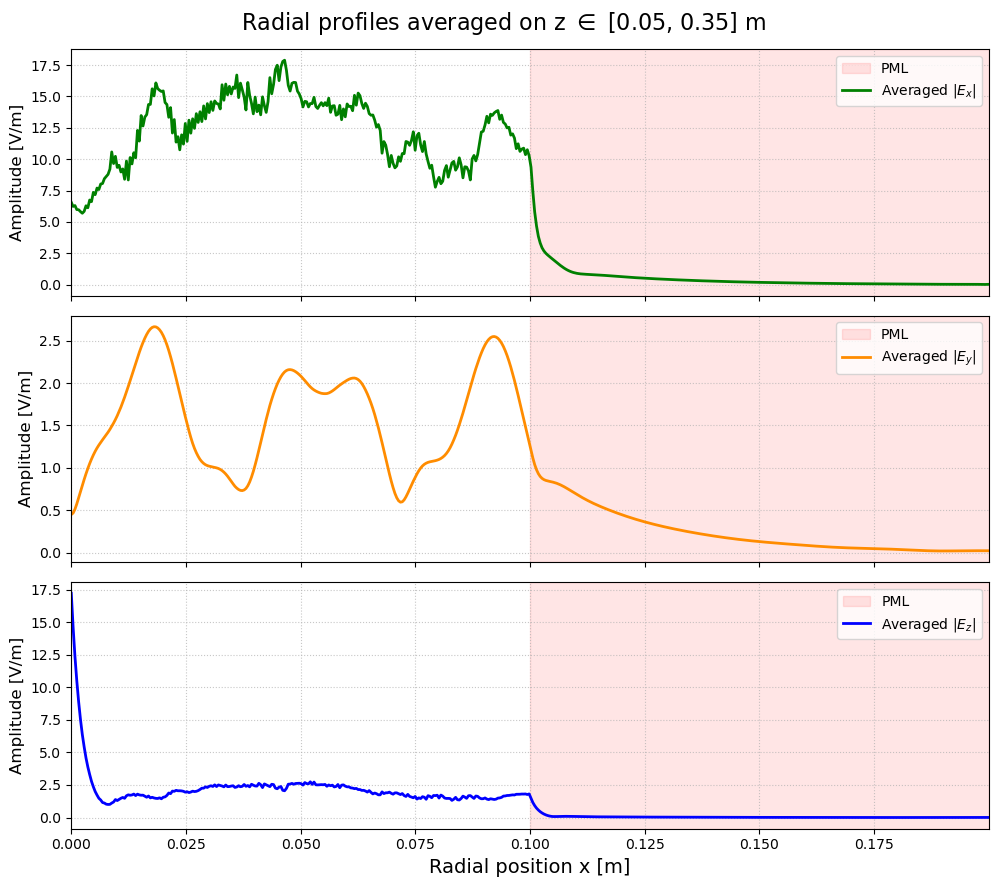

--- Plot Radial Component Averaged Function End---


In [ ]:
z_mid = cfg.DOMAIN['Lz_plasma'] / 2.0
# my_pp.plot_radial_components(solver, z_target=z_mid)
my_pp.Plot_Radial_Components_Averaged(solver, sim_target_folder)


--- [PLOT] 2D & 1D map generation of Density n_e ---
Compute Density_map and cutoff layer position.

--- Computing Density Map & Cutoff ---
Lx_tot=  0.2 Lx_plasma=  0.1 Lz_tot=  0.5051249432432433
len(X):  300
len(Z):  300
Selected density profile: constant_density
create_density_profile: prof_type =  constant_density
Computed Cutoff Density (n_c): 1.6982e+17 m^-3
Cutoff layer dynamically located at x = 0.0000 m
prof_type =  constant_density


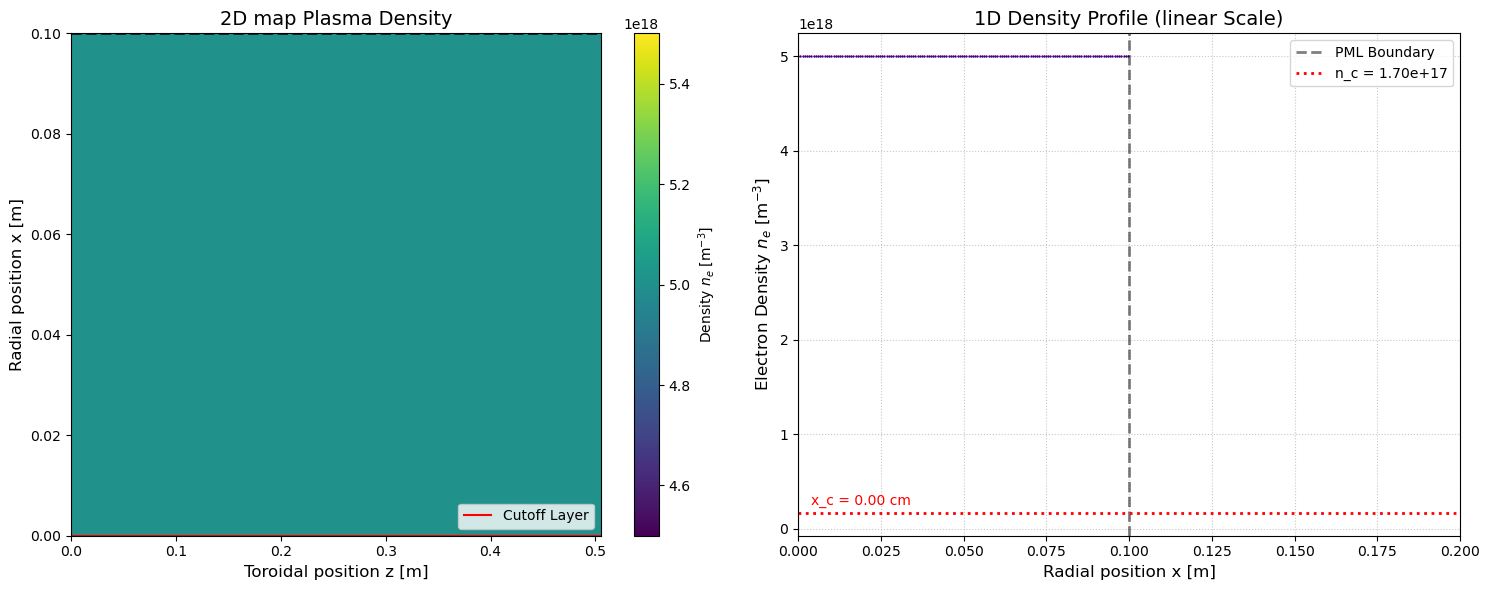

--- Plot Desnity Profile 2D Function End---
--- 2D map generation of (Magnetic Field B_tot + Vectors) ---


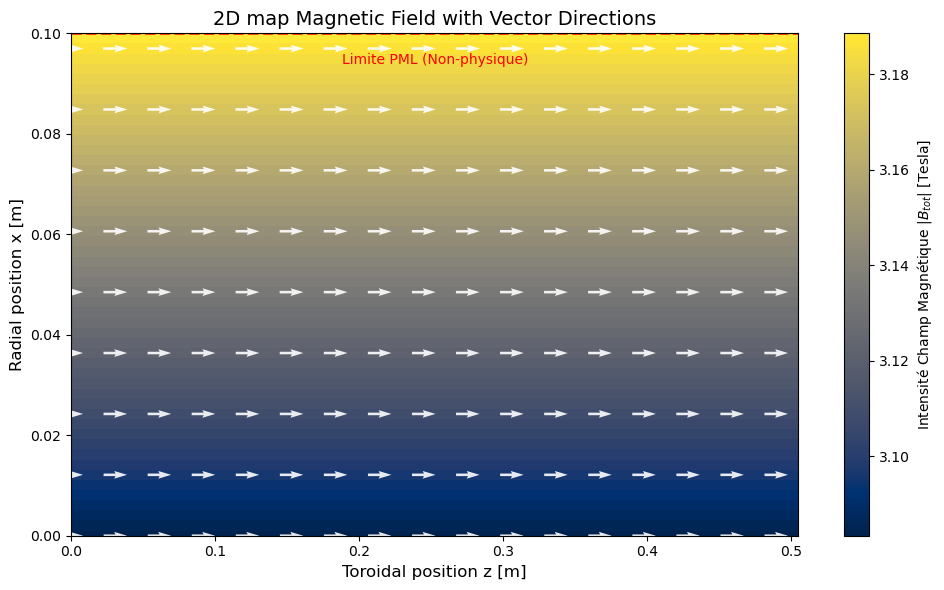

--- Plot B field Function End---


In [ ]:
my_pp.Plot_Density_Profile_2D(solver, sim_target_folder, resolution_x, resolution_z)

my_pp.Plot_B_Field_2D(solver, sim_target_folder)